In [ ]:
!apt-get install -y swig
!pip install gymnasium[box2d]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 34 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (7,002 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 126102 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubu

# 🚀 Giới thiệu bài toán Lunar Lander

## 1. Tổng quan
**Lunar Lander** là một môi trường mô phỏng trong bộ công cụ **OpenAI Gym**, được thiết kế nhằm hỗ trợ nghiên cứu và thử nghiệm các thuật toán **học tăng cường (Reinforcement Learning)**. Trong môi trường này, nhiệm vụ của tác nhân (agent) là điều khiển một **tàu đổ bộ mặt trăng (lander)** sao cho nó **hạ cánh an toàn** vào khu vực trung tâm được đánh dấu trên mặt đất.

Môi trường này mô phỏng theo thực tế với trọng lực, quán tính, va chạm, và tiêu hao nhiên liệu – từ đó tạo nên một bài toán mang tính thử thách và ứng dụng cao trong robot và điều khiển tự động.

---

## 2. Mục tiêu
- Học một **chính sách tối ưu** giúp tàu hạ cánh an toàn và tiết kiệm nhiên liệu.
- **Tối đa hóa tổng phần thưởng** trong suốt quá trình hạ cánh.
- **Môi trường sử dụng**: `LunarLander-v3`.

---

## 3. Trạng thái (State Space)
Trạng thái của môi trường được biểu diễn bằng một vector có 8 phần tử:

| Thành phần | Ý nghĩa |
|------------|---------|
| 1. `x` | Tọa độ ngang |
| 2. `y` | Tọa độ dọc |
| 3. `v_x` | Vận tốc theo trục x |
| 4. `v_y` | Vận tốc theo trục y |
| 5. `θ` | Góc quay của tàu |
| 6. `ω` | Tốc độ quay (angular velocity) |
| 7. `left_contact` | Chân trái tiếp đất (0 hoặc 1) |
| 8. `right_contact` | Chân phải tiếp đất (0 hoặc 1) |

---

## 4. Hành động (Action Space)
Môi trường có không gian hành động **rời rạc** gồm 4 lựa chọn:

| Hành động | Mô tả |
|-----------|------|
| 0 | Không làm gì |
| 1 | Bật động cơ chính (tạo lực đẩy thẳng đứng) |
| 2 | Bật động cơ bên trái (xoay tàu sang phải) |
| 3 | Bật động cơ bên phải (xoay tàu sang trái) |

---

## 5. Phần thưởng (Reward)
- **+100 đến +140**: khi hạ cánh an toàn vào khu vực trung tâm.
- **+10**: mỗi chân tiếp đất.
- **-0.03 mỗi khung hình** nếu sử dụng động cơ (để khuyến khích tiết kiệm nhiên liệu).
- **-100**: nếu tàu rơi hoặc bay ra ngoài màn hình.
- **0 phần thưởng** nếu vẫn đang lơ lửng và chưa chạm đất.

---

## 6. Điều kiện kết thúc (Termination)
Tập được kết thúc khi:
- Tàu tiếp đất (thành công hoặc va chạm).
- Tàu bay ra ngoài khu vực màn hình.
- Số bước vượt quá giới hạn tối đa (thường là 1000 bước).

---

## 7. Mục tiêu của thuật toán học tăng cường
- Tìm ra chính sách (policy) tối ưu để tối đa hóa phần thưởng tổng cộng.
- Giúp agent học cách **giảm độ cao hợp lý**, **cân bằng tàu**, **điều chỉnh hướng bay**, và **tiếp đất nhẹ nhàng bằng cả hai chân**.

---

## 8. Một số thuật toán áp dụng phổ biến
- **DQN (Deep Q-Network)**
- **Double DQN**
- **Dueling DQN**
- **PPO (Proximal Policy Optimization)**
- **A2C (Advantage Actor Critic)**
- **Rainbow DQN**

---

## 9. Ứng dụng thực tiễn
- Điều khiển tàu vũ trụ hoặc máy bay không người lái.
- Bài toán mẫu cho nghiên cứu học tăng cường.
- Mô phỏng robot trong môi trường vật lý khó khăn.

---

📌 *Lunar Lander là một môi trường cổ điển nhưng vẫn giữ vai trò quan trọng trong việc kiểm nghiệm độ hiệu quả của các thuật toán học tăng cường, từ đơn giản đến phức tạp.*


## **DQN (Deep Q-learning)**  

#### 1. Lý do lựa chọn DQN

Thuật toán **Deep Q-Network (DQN)** là một lựa chọn phù hợp để giải bài toán **Lunar Lander** vì các lý do sau:

- ✅ **Không gian trạng thái liên tục**: Lunar Lander có không gian trạng thái là một vector 8 chiều thực, nên Q-learning truyền thống dùng bảng Q không khả thi.
- ✅ **DQN sử dụng mạng neural để xấp xỉ hàm Q**, giúp xử lý tốt các bài toán có không gian trạng thái lớn.
- ✅ **Ổn định và hiệu quả**: DQN sử dụng các kỹ thuật như Replay Buffer và Target Network để tăng tính ổn định trong huấn luyện.
- ✅ Dễ triển khai và là nền tảng của nhiều thuật toán nâng cao (Double DQN, Dueling DQN, Rainbow...).

---

#### 2. Lý thuyết của thuật toán DQN

##### a. Q-learning truyền thống

Q-learning là một thuật toán học tăng cường off-policy. Mục tiêu là học hàm giá trị hành động \( Q(s, a) \) – đại diện cho giá trị kỳ vọng phần thưởng trong tương lai khi thực hiện hành động \( a \) tại trạng thái \( s \), sau đó đi theo chính sách tối ưu.

Công thức cập nhật:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]
$$

Trong đó:

- $\alpha$: learning rate.
- $\gamma$: hệ số chiết khấu (discount factor), xác định tầm quan trọng của phần thưởng tương lai
- $r$: phần thưởng nhận được khi thực hiện hành động $a$ tại trạng thái $s$.
- $s'$: trạng thái kế tiếp
- $\max_{a'} Q(s', a')$: giá trị hành động tốt nhất tại trạng thái mới
---

### 🔹 b. DQN – Deep Q-Network

**DQN** (Deep Q-Network) là một biến thể của Q-learning, trong đó **bảng Q rời rạc** được thay thế bằng một **mạng neural sâu** $Q(s, a; \theta)$. Điều này cho phép thuật toán xử lý các môi trường có:

- **Không gian trạng thái liên tục hoặc rất lớn**, nơi việc lưu trữ bảng Q truyền thống không còn khả thi.

---

#### ✅ Kiến trúc của DQN:

- $\theta$: các tham số (trọng số) của **mạng chính** (còn gọi là *policy network*), dùng để ước lượng hàm Q.
- DQN sử dụng một bộ nhớ gọi là **Replay Buffer** $D$, nơi lưu trữ các kinh nghiệm quá khứ dưới dạng $(s, a, r, s')$. Việc lấy mẫu ngẫu nhiên từ buffer giúp **giảm tương quan giữa các mẫu** và làm cho việc huấn luyện ổn định hơn.

---

#### ✅ Hàm mất mát (Loss function):

DQN huấn luyện mạng $Q(s, a; \theta)$ bằng cách làm cho đầu ra của nó gần với **Q-target** – giá trị mục tiêu được tính toán riêng.

$$
\mathcal{L}(\theta) = \mathbb{E}_{(s, a, r, s') \sim D} \left[ \left(\underbrace{y}_{\text{Q-target}} - Q(s, a; \theta) \right)^2 \right]
$$

Trong đó, **Q-target** $y$ được tính như sau:

$$
y = r + \gamma \max_{a'} Q(s', a'; \theta^-)
$$

- $\gamma$: hệ số chiết khấu (*discount factor*), thể hiện tầm quan trọng của phần thưởng tương lai.
- $\theta^-$: tham số của **mạng Q-target** (*target network*), là bản sao tạm thời của $\theta$ và được **cập nhật định kỳ** từ *policy network* để đảm bảo tính ổn định.

---

#### ✅ Vai trò của Q-target và target network:

- Nếu sử dụng cùng một mạng để **chọn hành động tốt nhất tại trạng thái mới $s'$** và **ước lượng giá trị của hành động đó**, việc học sẽ dễ bị **không ổn định**.
- Vì vậy, DQN dùng **một target network riêng biệt** để tính Q-target – giúp tách biệt hai quá trình này, từ đó làm giảm dao động và tăng độ ổn định trong huấn luyện.

---

### 📌 Tóm tắt:

- **$Q(s, a; \theta)$**: được học bởi *policy network*, biểu diễn giá trị hành động hiện tại.
- **Q-target $y$**: được tính bằng *target network*, dùng làm nhãn để huấn luyện *policy network*.
- DQN dùng **replay buffer** để học từ kinh nghiệm quá khứ, và **target network** để tính Q-target một cách ổn định.


- $ \theta^-$: tham số của **target network** (mạng Q mục tiêu).
- $ D $: Replay Buffer – bộ nhớ lưu các kinh nghiệm \((s, a, r, s')\).






## Các bước thực hiện thuật toán DQN

a. Chuẩn bị môi trường

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import collections
from IPython.display import HTML

from collections import deque
from tqdm import tqdm # Ensure tqdm is imported here
import imageio # Ensure imageio is imported here
import base64 # Ensure base64 is imported here
import io # Ensure io is imported here
import glob # Ensure glob is imported here

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(device)

cpu


### Khởi tạo mạng
- state_size : số chiều của trạng thái môi trường (8 trạng thái của agent)
- action_size: số hoạt động của agent trong môi trường
- hidden_size: số nơ ron ở bên trong tầng ẩn của mạng

Khởi tạo mạng nơ ron với 3 lớp
- fc1: lớp fully connected đầu tiên, ánh xạ từ không gian trạng thái sang không gian ẩn
- fc2 lớp fully connected thứ hai khi nhận đầu vào là fc1, tiếp tục trích xuất đầu ra sâu hơn
- fc3 lớp fully connected cuối cùng ánh xạ từ không gian trạng thái ẩn sang không gian hành động, đầu ra là Q_value cho mỗi hành động tại trạng thái hiện tại

Mạng sử dụng activation function là Relu

In [ ]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=128):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

### Replay Buffer
Lưu trữ kinh nghiệm: Mỗi khi agent tương tác với môi trường, bộ nhớ sẽ lưu trữ một bộ dữ liệu:
 $$
  (s, a, r, s', done)
  $$
Trong đó:
- $s$ là trạng thái hiện tại
- $a$: là hành động được chọn
- $r$: phần thưởng nhận được.
- $s'$: trạng thái tiếp theo.
- done: đánh dấu kết thúc episode.

#### Cách hoạt động:
1. **Khi agent tương tác với môi trường**, mỗi transition sẽ được thêm vào buffer.
2. **Khi buffer đủ lớn** (đạt batch size), ta sẽ:
   - Lấy ngẫu nhiên một mini-batch từ buffer.
   - Dùng các sample này để huấn luyện mạng Q (bằng cách tính loss giữa Q hiện tại và Q-target).
3. **Nếu buffer đầy**, các mẫu cũ nhất sẽ bị loại bỏ để nhường chỗ cho mẫu mới hơn (FIFO).



In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states = torch.FloatTensor([item[0] for item in batch]).to(device)
        actions = torch.LongTensor([item[1] for item in batch]).to(device)
        rewards = torch.FloatTensor([item[2] for item in batch]).to(device)
        next_states = torch.FloatTensor([item[3] for item in batch]).to(device)
        dones = torch.FloatTensor([item[4] for item in batch]).to(device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)


### Epsilon-Greedy Policy để chọn hành động:
   - Chính sách hành động để cân bằng giữa khám phá (exploration) và khai thác (exploitation):

$$
a =
\begin{cases}
\text{ngẫu nhiên}, & \text{với xác suất } \varepsilon \\
\arg\max_a Q(s, a), & \text{với xác suất } 1 - \varepsilon
\end{cases}
$$


In [ ]:
def select_action(state, eps, policy_net, n_actions):
    if random.random() > eps:
        with torch.no_grad():
            state = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = policy_net(state)
            return q_values.max(1)[1].item()
    else:
        return random.randrange(n_actions)

### Tóm tắt chiến lược huấn luyện DQN

  1. **Khởi tạo môi trường và mạng:**
    - Môi trường `env` (ví dụ LunarLander-v3).
    - Hai mạng neural: `policy_net` (mạng chính) và `target_net` (mạng mục tiêu).
    - Bộ nhớ replay buffer (`memory`) với sức chứa lớn (100,000 mẫu).
    - Bộ tối ưu Adam với learning rate 0.0001.



  2. **Quy trình huấn luyện:**
    - Với mỗi episode:
      - Khởi tạo trạng thái ban đầu.
      - Lặp qua từng bước trong episode:
        - Chọn hành động theo chính sách epsilon-greedy từ `policy_net`.
        - Thực hiện hành động, nhận phần thưởng và trạng thái kế tiếp.
        - Lưu transition `(state, action, reward, next_state, done)` vào replay buffer.
        - Nếu replay buffer đủ lớn, lấy mẫu ngẫu nhiên một batch để huấn luyện:
          - Tính giá trị Q hiện tại từ `policy_net`.
          - Tính giá trị Q mục tiêu (target Q) dùng `target_net`.
          - Tính loss MSE giữa Q hiện tại và target Q, cập nhật trọng số `policy_net`.
        - Cập nhật `target_net` theo `policy_net` sau mỗi 1000 bước.
      - Giảm dần epsilon để tăng tỷ lệ exploitation.
      - Lưu tổng phần thưởng của episode.

  4. **Theo dõi và đánh giá:**
    - In ra phần thưởng trung bình mỗi 100 episode.
    - Vẽ đồ thị phần thưởng từng episode và trung bình 100 episode.



In [ ]:
def trainAgent_default(env,
               n_episodes=1000,
               batch_size=64,
               gamma=0.99,
               learning_rate=0.0001,
               memory_size=100000,
               eps_start=1.0,
               eps_end=0.01,
               eps_decay=0.995,
               target_update=1000):
    # Khởi tạo môi trường và các thành phần
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    policy_net = DQN(state_size, action_size).to(device)
    target_net = DQN(state_size, action_size).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
    memory = ReplayBuffer(memory_size)

    scores = []
    eps = eps_start
    total_steps = 0

    # GIỮ NGUYÊN vòng for block_start của bạn
    for block_start in range(0, n_episodes, 100):
        for episode in tqdm(range(block_start, min(block_start + 100, n_episodes)), desc="Training Episodes"):
            state, _ = env.reset()
            total_reward = 0
            done = False

            while not done:
                action = select_action(state, eps, policy_net, action_size)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                total_reward += reward
                memory.push(state, action, reward, next_state, done)
                state = next_state
                total_steps += 1

                if len(memory) > batch_size:
                    states, actions, rewards, next_states, dones = memory.sample(batch_size)
                    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                    with torch.no_grad():
                        next_q_values = target_net(next_states).max(1)[0]
                        target_q = rewards + gamma * next_q_values * (1 - dones)
                    loss = nn.MSELoss()(q_values, target_q)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                if total_steps % target_update == 0:
                    target_net.load_state_dict(policy_net.state_dict())

            eps = max(eps_end, eps_decay * eps)
            scores.append(total_reward)

        # Báo cáo reward trung bình mỗi block
        avg_reward = np.mean(scores[-100:])
        print(f"Episodes {block_start+1}-{min(block_start+100, n_episodes)}: "
              f"Avg Reward={avg_reward:.2f}, Epsilon={eps:.3f}")

    env.close()
    return policy_net, scores


Theo dõi với tham số learning rate = 0.001 và gamma bằng 0.95

In [ ]:
# Huấn luyện
env = gym.make('LunarLander-v3')
policy_net0, scores0 = trainAgent_default(env, learning_rate= 0.001, gamma= 0.95)

Training Episodes: 100%|██████████| 100/100 [00:39<00:00,  2.55it/s]


Episodes 1-100: Avg Reward=-138.85, Epsilon=0.606


Training Episodes: 100%|██████████| 100/100 [01:53<00:00,  1.13s/it]


Episodes 101-200: Avg Reward=-40.59, Epsilon=0.367


Training Episodes: 100%|██████████| 100/100 [04:54<00:00,  2.95s/it]


...

Episodes 701-800: Avg Reward=-78.89, Epsilon=0.018


Training Episodes: 100%|██████████| 100/100 [06:12<00:00,  3.73s/it]


Episodes 801-900: Avg Reward=-84.93, Epsilon=0.011


Training Episodes: 100%|██████████| 100/100 [06:52<00:00,  4.12s/it]

Episodes 901-1000: Avg Reward=-83.43, Epsilon=0.010


Theo dõi với tham số learning rate = 0.001 và gamma = 0.99

In [ ]:
# Huấn luyện
env = gym.make('LunarLander-v3')
policy_net, scores = trainAgent_default(env, learning_rate= 0.001, gamma= 0.99)

Training Episodes: 100%|██████████| 100/100 [00:37<00:00,  2.66it/s]


Episodes 1-100: Avg Reward=-145.45, Epsilon=0.606


Training Episodes: 100%|██████████| 100/100 [01:34<00:00,  1.06it/s]


Episodes 101-200: Avg Reward=-48.19, Epsilon=0.367


Training Episodes: 100%|██████████| 100/100 [03:56<00:00,  2.37s/it]


...

Episodes 701-800: Avg Reward=201.34, Epsilon=0.018


Training Episodes: 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]


Episodes 801-900: Avg Reward=152.60, Epsilon=0.011


Training Episodes: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]

Episodes 901-1000: Avg Reward=234.54, Epsilon=0.010


Theo dõi với tham số learning rate = 0.0001 và gamma = 0.99

In [ ]:
# Huấn luyện
env = gym.make('LunarLander-v3')
policy_net1, scores1 = trainAgent_default(env, learning_rate= 0.0001, gamma= 0.99)

Training Episodes: 100%|██████████| 100/100 [00:33<00:00,  2.94it/s]


Episodes 1-100: Average reward = -163.78, Epsilon = 0.606


Training Episodes: 100%|██████████| 100/100 [02:17<00:00,  1.38s/it]


Episodes 101-200: Average reward = -57.27, Epsilon = 0.367


Training Episodes: 100%|██████████| 100/100 [05:17<00:00,  3.18s/it]


...

Episodes 701-800: Average reward = 263.73, Epsilon = 0.018


Training Episodes: 100%|██████████| 100/100 [01:42<00:00,  1.02s/it]


Episodes 801-900: Average reward = 270.12, Epsilon = 0.011


Training Episodes: 100%|██████████| 100/100 [01:43<00:00,  1.04s/it]

Episodes 901-1000: Average reward = 265.90, Epsilon = 0.010


### Huấn luyện mô hình với tinh chỉnh tham số nhằm tăng hiệu suất hạ cánh và tiết kiệm nhiên liệu
- Sử dụng custom_reward tinh chỉnh điểm thưởng
-Tích hợp tinh chỉnh điểm thưởng vào quá trình huấn luyện

In [ ]:

# Hàm custom_reward (được cải tiến với giới hạn)
def custom_reward(state, action, reward, next_state, done):
    x_pos = next_state[0]         # Vị trí ngang
    y_pos = next_state[1]         # Độ cao
    x_vel = next_state[2]         # Vận tốc ngang
    y_vel = next_state[3]         # Vận tốc thẳng đứng
    angle = next_state[4]         # Góc nghiêng
    angular_vel = next_state[5]   # Vận tốc quay
    contact_left = next_state[6]  # Tiếp đất chân trái
    contact_right = next_state[7] # Tiếp đất chân phải

    shaped_reward = 0  # Bắt đầu từ 0, không cộng reward gốc ngay

    # Khuyến khích giữ gần vị trí hạ cánh
    shaped_reward += 0.3 * (0.5 - abs(x_pos))

    # Khuyến khích giữ cân bằng
    if angle > 0 and action == 3 and x_pos > 0:  # nghiêng phải, dùng động cơ phải
        shaped_reward += 0.3
    elif angle < 0 and action == 1 and x_pos < 0:  # nghiêng trái, dùng động cơ trái
        shaped_reward += 0.3

    # Thưởng/phạt khi tiếp đất
    if contact_left and contact_right:
        if abs(angle) > 0.1 and abs(x_pos) > 0.2:
            if action == 2:  # dùng động cơ chính để đứng dậy
                shaped_reward += 10
            else:
                shaped_reward -= 5

    # Hình phạt tiết kiệm nhiên liệu
    if action == 1 or action == 3:  # Động cơ trái/phải
        shaped_reward -= 0.2
    if action == 2:  # Động cơ chính
        shaped_reward -= 0.7

    # Thưởng/phạt khi tốc độ quay lớn
    if abs(angular_vel) > 0.5:
        if angular_vel > 0:
            if action == 1:
                shaped_reward += 0.3
            elif action == 3:
                shaped_reward -= 0.5
        else:
            if action == 3:
                shaped_reward += 0.3
            elif action == 1:
                shaped_reward -= 0.5
        if action == 0:
            shaped_reward -= 0.5

    # Hình phạt nếu rơi
    if done and not (contact_left and contact_right):
        shaped_reward -= 30

    # Phạt nếu tiếp đất thô bạo
    if done and y_pos < 0.3 and abs(y_vel) > 0.2:
        shaped_reward -= 5

    # Thưởng khi hạ cánh thành công
    if done and contact_left and contact_right:
        shaped_reward += (0.4 - abs(x_pos)) * 10  # Giảm hệ số từ 30 xuống 10 để tránh quá cao

    # Giới hạn phần thưởng mỗi bước
    shaped_reward = min(max(shaped_reward, -10), 10)

    return shaped_reward + reward  # Cộng thêm reward gốc để tổng hợp



In [ ]:
from tqdm import tqdm
def train_dqn_custom():
    env = gym.make("LunarLander-v3")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy_net = DQN(obs_dim, n_actions)
    target_net = DQN(obs_dim, n_actions)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=0.0001)
    replay_buffer = ReplayBuffer(100000)

    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 1000
    num_episodes = 1000

    total_steps = 0
    episode_rewards = []

    for block_start in range(0, num_episodes, 100):
        for episode in tqdm(range(block_start, min(block_start + 100, num_episodes)),
                            desc=f"Training Episodes "):
            state, _ = env.reset()
            total_reward = 0
            done = False

            while not done:
                action = select_action(state, epsilon, policy_net, n_actions)

                next_state, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                reward_shaped = custom_reward(state, action, reward, next_state, terminated or truncated)
                total_reward_shaped = reward + reward_shaped

                done = terminated or truncated

                replay_buffer.push(state, action, total_reward_shaped, next_state, done)
                state = next_state

                total_steps += 1

                if len(replay_buffer) > batch_size:
                    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
                    with torch.no_grad():
                        next_q_values = target_net(next_states).max(1)[0]
                        target_q = rewards + gamma * next_q_values * (1 - dones)

                    loss = nn.MSELoss()(q_values, target_q)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                if total_steps % target_update_freq == 0:
                    target_net.load_state_dict(policy_net.state_dict())

            epsilon = max(epsilon * epsilon_decay, epsilon_min)
            episode_rewards.append(total_reward)

        avg = np.mean(episode_rewards[-100:])
        print(f"Episodes {block_start + 1}-{min(block_start + 100, num_episodes)}: "
              f"Average reward = {avg:.2f}, Epsilon = {epsilon:.3f}")

    env.close()
    return policy_net, episode_rewards

In [ ]:
# Huấn luyện
env = gym.make('LunarLander-v3')
policy_net2, scores2 = train_dqn_custom()




Training Episodes : 100%|██████████| 100/100 [00:49<00:00,  2.04it/s]


Episodes 1-100: Average reward = -154.23, Epsilon = 0.606


Training Episodes : 100%|██████████| 100/100 [02:23<00:00,  1.44s/it]


Episodes 101-200: Average reward = -69.71, Epsilon = 0.367


Training Episodes : 100%|██████████| 100/100 [05:28<00:00,  3.28s/it]


...

Episodes 701-800: Average reward = 268.24, Epsilon = 0.018


Training Episodes : 100%|██████████| 100/100 [01:33<00:00,  1.06it/s]


Episodes 801-900: Average reward = 264.65, Epsilon = 0.011


Training Episodes : 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]

Episodes 901-1000: Average reward = 276.82, Epsilon = 0.010


## **DDQN (Double DQN)**  
DDQN cải tiến từ DQN nhằm giảm sự **quá lạc quan** trong ước lượng giá trị hành động.

### **Nguyên lý hoạt động**
- **Chọn hành động:**  
  - Vẫn sử dụng **policy network** để chọn hành động tốt nhất:
    $
    a^* = \arg\max_{a'} Q_{\text{policy}}(s', a')
    $
- **Đánh giá giá trị:**  
  - Sử dụng **target network** để đánh giá Q-value của hành động đó:
    $
    y = r + \gamma Q_{\text{target}}(s', a^*)
    $
- **Ưu điểm:**  
  - Giảm bias quá lạc quan, giúp học **ổn định hơn** và hội tụ tốt hơn.

---

## ⚡ **Khác biệt chính giữa DQN và DDQN**

| Đặc điểm                 | DQN                                                         | DDQN                                                       |
|--------------------------|-------------------------------------------------------------|-----------------------------------------------------------|
| **Cách chọn hành động**   | Chọn $ a^*$ từ **target network**                       | Chọn  $a^*$ từ **policy network**                      |
| **Cách tính Q-target**    | $ y = r + \gamma \max_{a'} Q_{\text{target}}(s', a')$   | $y = r + \gamma Q_{\text{target}}(s', a^*)$           |
| **Vấn đề chính**          | Overestimation bias (quá lạc quan)                         | Giảm overestimation bias                                  |
| **Hiệu quả học**          | Dễ dao động, chậm hội tụ                                   | Ổn định hơn, hội tụ nhanh hơn                             |
| **Độ phức tạp tính toán** | Đơn giản hơn                                               | Phức tạp hơn một chút (do cần 2 mạng để chọn và đánh giá) |

---

## 📌 **Khi nào dùng DDQN thay cho DQN?**
- Khi bài toán có **không gian trạng thái lớn**, nhiều trạng thái dễ gây **quá lạc quan**.  
- Khi muốn **tăng độ ổn định học** và giảm dao động reward.  






Train DDQN với điểm thưởng mặc định của môi trường với learning_rate = 0.001

In [ ]:
def trainAgent_double_q1(
    env,
    n_episodes=1000,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.995,
    target_update=1000,
    lr=0.0001,
    gamma=0.99,
    batch_size=64,
    replay_size=100000
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    policy_net = DQN(state_size, action_size).to(device)
    target_net = DQN(state_size, action_size).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    memory = ReplayBuffer(replay_size)

    scores = []
    eps = eps_start
    total_steps = 0

    for block_start in range(0, n_episodes, 100):
        for episode in tqdm(range(block_start, min(block_start + 100, n_episodes)), desc="Training Episodes"):
            state, _ = env.reset()
            total_reward = 0
            done = False

            while not done:
                action = select_action(state, eps, policy_net, action_size)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                total_reward += reward

                memory.push(state, action, reward, next_state, done)
                state = next_state
                total_steps += 1

                if len(memory) > batch_size:
                    states, actions, rewards, next_states, dones = memory.sample(batch_size)

                    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()

                    with torch.no_grad():
                        next_actions = policy_net(next_states).argmax(1)
                        next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
                        target_q = rewards + gamma * next_q_values * (1 - dones)

                    loss = nn.MSELoss()(q_values, target_q)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                if total_steps % target_update == 0:
                    target_net.load_state_dict(policy_net.state_dict())

            eps = max(eps_end, eps_decay * eps)
            scores.append(total_reward)

        avg = np.mean(scores[-100:])
        print(f"Episodes {block_start + 1}-{min(block_start + 100, n_episodes)}: "
              f"Average reward = {avg:.2f}, Epsilon = {eps:.3f}")

    env.close()
    return policy_net, scores


In [ ]:
env = gym.make("LunarLander-v3")
policy_net3, scores3 = trainAgent_double_q1(env, n_episodes= 1000, lr= 0.001, gamma=0.95)

Training Episodes:   0%|          | 0/100 [00:00<?, ?it/s]<ipython-input-6-3cc62194181f>:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.FloatTensor([item[0] for item in batch]).to(device)
Training Episodes: 100%|██████████| 100/100 [00:33<00:00,  2.95it/s]


Episodes 1-100: Average reward = -123.31, Epsilon = 0.606


Training Episodes: 100%|██████████| 100/100 [01:15<00:00,  1.33it/s]


Episodes 101-200: Average reward = -74.62, Epsilon = 0.367


Training Episodes: 100%|██████████| 100/100 [04:53<00:00,  2.94s/it]


...

Episodes 701-800: Average reward = -95.77, Epsilon = 0.018


Training Episodes: 100%|██████████| 100/100 [06:49<00:00,  4.10s/it]


Episodes 801-900: Average reward = -68.37, Epsilon = 0.011


Training Episodes: 100%|██████████| 100/100 [06:21<00:00,  3.82s/it]

Episodes 901-1000: Average reward = -74.63, Epsilon = 0.010


### Nhận xét:
- Với Learning Rate = 0.001 ta thấy được Agent học không ổn định, biểu đồ thể hiện điểm thưởng giao động rất lớn, không hội tụ, ở những vị trí bị phạt rất nặng => không hiệu quả.
- Giải pháp đưa ra: giảm learning rate để có thể train một cách hiệu quả hơn

Thay đổi gamma = 0.99 và Learning Rate = 0.001, giữ điểm thưởng mặc định của môi trường và episode = 1000

In [ ]:
env = gym.make("LunarLander-v3")
policy_net5, scores5 = trainAgent_double_q1(env, n_episodes= 1000, lr= 0.0001, gamma=0.99)

Training Episodes: 100%|██████████| 100/100 [00:43<00:00,  2.31it/s]


Episodes 1-100: Average reward = -154.98, Epsilon = 0.606


Training Episodes: 100%|██████████| 100/100 [01:45<00:00,  1.06s/it]


Episodes 101-200: Average reward = -50.53, Epsilon = 0.367


Training Episodes: 100%|██████████| 100/100 [05:16<00:00,  3.17s/it]


...

Episodes 701-800: Average reward = 251.53, Epsilon = 0.018


Training Episodes: 100%|██████████| 100/100 [01:55<00:00,  1.15s/it]


Episodes 801-900: Average reward = 259.93, Epsilon = 0.011


Training Episodes: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]

Episodes 901-1000: Average reward = 270.54, Epsilon = 0.010


Thay đổi Learning Rate = 0.0001 và gamma = 0.99 và giữ điểm thưởng mặc định của môi trường, nâng số episode lên 1500 để cho Agent có khả năng học rộng hơn.

In [ ]:
env = gym.make("LunarLander-v3")
policy_net4, scores4 = trainAgent_double_q1(env, n_episodes= 1500, lr= 0.0001, gamma=0.99)

Training Episodes: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]


Episodes 1-100: Average reward = -130.97, Epsilon = 0.606


Training Episodes: 100%|██████████| 100/100 [01:49<00:00,  1.10s/it]


Episodes 101-200: Average reward = -72.45, Epsilon = 0.367


Training Episodes: 100%|██████████| 100/100 [06:08<00:00,  3.69s/it]


...

Episodes 1201-1300: Average reward = 260.12, Epsilon = 0.010


Training Episodes: 100%|██████████| 100/100 [01:58<00:00,  1.18s/it]


Episodes 1301-1400: Average reward = 264.03, Epsilon = 0.010


Training Episodes: 100%|██████████| 100/100 [01:54<00:00,  1.15s/it]

Episodes 1401-1500: Average reward = 260.75, Epsilon = 0.010


## Double DQN với custom reward

In [ ]:


def train_ddqn_custom(learning_rate):
    env = gym.make("LunarLander-v3")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    policy_net = DQN(obs_dim, n_actions)
    target_net = DQN(obs_dim, n_actions)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr= learning_rate)
    replay_buffer = ReplayBuffer(100000)

    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update_freq = 1000
    num_episodes = 1000

    total_steps = 0
    episode_rewards = []

    for block_start in range(0, num_episodes, 100):
        for episode in tqdm(range(block_start, min(block_start + 100, num_episodes)),
                            desc=f"Training Episodes "):
            state, _ = env.reset()
            total_reward = 0
            done = False

            while not done:
                action = select_action(state, epsilon, policy_net, n_actions)

                next_state, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                reward_shaped = custom_reward(state, action, reward, next_state, terminated or truncated)
                total_reward_shaped = reward + reward_shaped

                done = terminated or truncated

                replay_buffer.push(state, action, total_reward_shaped, next_state, done)
                state = next_state

                total_steps += 1

                if len(replay_buffer) > batch_size:
                    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

                    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()

                    # -------- DOUBLE DQN UPDATE --------
                    with torch.no_grad():
                        # Chọn action tốt nhất bằng policy_net
                        next_actions = policy_net(next_states).argmax(1)
                        # Đánh giá action đó bằng target_net
                        next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()
                        # Tính target
                        target_q = rewards + gamma * next_q_values * (1 - dones)
                    # ------------------------------------

                    loss = nn.MSELoss()(q_values, target_q)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                if total_steps % target_update_freq == 0:
                    target_net.load_state_dict(policy_net.state_dict())

            epsilon = max(epsilon * epsilon_decay, epsilon_min)
            episode_rewards.append(total_reward)

        avg = np.mean(episode_rewards[-100:])
        print(f"Episodes {block_start + 1}-{min(block_start + 100, num_episodes)}: "
              f"Average reward = {avg:.2f}, Epsilon = {epsilon:.3f}")

    env.close()
    return policy_net, episode_rewards


In [ ]:
env = gym.make("LunarLander-v3")
train_ddqn_custom1 , ddqn_custom_rewards1 = train_ddqn_custom(learning_rate= 0.0001)


Training Episodes :   0%|          | 0/100 [00:00<?, ?it/s]<ipython-input-6-3cc62194181f>:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.FloatTensor([item[0] for item in batch]).to(device)
Training Episodes : 100%|██████████| 100/100 [00:34<00:00,  2.89it/s]


Episodes 1-100: Average reward = -152.73, Epsilon = 0.606


Training Episodes : 100%|██████████| 100/100 [02:06<00:00,  1.27s/it]


Episodes 101-200: Average reward = -66.46, Epsilon = 0.367


Training Episodes : 100%|██████████| 100/100 [05:28<00:00,  3.29s/it]


...

Episodes 701-800: Average reward = 256.14, Epsilon = 0.018


Training Episodes : 100%|██████████| 100/100 [01:53<00:00,  1.14s/it]


Episodes 801-900: Average reward = 263.98, Epsilon = 0.011


Training Episodes : 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]

Episodes 901-1000: Average reward = 267.25, Epsilon = 0.010


### Kết quả đánh giá mô hình


1. Đánh giá thông qua biểu đồ thể hiện điểm thưởng
- Vẽ biểu đồ đường thể hiện tương quan của đường trung bình điểm thưởng và điểm thưởng qua từng episode

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rewards(episode_rewards, window=50):
    """
    Vẽ đồ thị điểm thưởng qua từng tập và điểm thưởng trung bình trượt.

    Args:
        episode_rewards (list): Danh sách điểm thưởng theo từng tập.
        window (int): Kích thước cửa sổ trung bình trượt.
    """
    plt.figure(figsize=(12, 6))
    plt.plot(episode_rewards, label='Reward per Episode', color='lightblue')

    # Tính trung bình trượt
    if len(episode_rewards) >= window:
        moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window - 1, len(episode_rewards)), moving_avg, label=f'{window}-Episode Moving Average', color='orange')

    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('DQN Training Performance')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


2. Video Output

In [ ]:


def show_video_of_model(policy_net, env_name, n_actions):
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset()
    done = False
    frames = []

    while not done:
        frame = env.render()
        frames.append(frame)
        action = select_action(state, eps=0.01, policy_net=policy_net, n_actions=n_actions)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()
    imageio.mimsave('video.mp4', frames, fps=30)

def show_video():
    mp4list = glob.glob('*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display(HTML(data=f'''<video alt="test" autoplay
                    loop controls style="height: 400px;">
                    <source src="data:video/mp4;base64,{encoded.decode('ascii')}" type="video/mp4" />
                 </video>'''))
    else:
        print("Could not find video")


3. Đánh giá tỉ lệ thành công

## 📊 **Tóm tắt cách tính trong `test_success_rate`**

Hàm `test_success_rate` đánh giá **tỷ lệ thành công**, **phần thưởng trung bình**, và **hiệu suất nhiên liệu** của mạng chính sách trong môi trường.

### 🔍 **Cách tính:**
- **Chọn hành động:**  
  Chọn $ a = \arg\max Q_{\text{policy}}(s) $.

- **Tổng phần thưởng (`total_reward`)**:  
  Cộng dồn reward trong mỗi tập.

- **Tính số lần dùng động cơ:**  
  - Động cơ chính: `action == 2`.  
  - Động cơ bên: `action == 1 hoặc 3`.

- **Hạ cánh thành công:**  
  Nếu tiếp xúc đất (`contact_left/right == 1.0`) và $ \text{total_reward} \geq 200 $.

- **Hiệu suất nhiên liệu:**  
  $$ \text{Fuel Efficiency} = \frac{\text{Total Reward}}{\text{Main Use} + 0.2 \times \text{Side Use}} $$

- **Kết quả cuối cùng:**  
  - **Success Rate:** Số tập thành công / Tổng tập.  
  - **Average Reward:** Trung bình phần thưởng.  
  - **Average Fuel Efficiency:** Trung bình hiệu suất nhiên liệu.



In [ ]:
def test_success_rate(env, policy_net, n_episodes=100, render=False, verbose=False):
    policy_net.eval()
    success_count = 0
    total_rewards = []
    fuel_efficiencies = []

    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        success = False
        main_engine_use = 0
        side_engine_use = 0

        while not done:
            if render:
                env.render()

            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                action = policy_net(state_tensor).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            # Đếm số lần dùng động cơ
            if action == 2:
                main_engine_use += 1
            elif action in [1, 3]:
                side_engine_use += 1

            # Kiểm tra điều kiện hạ cánh thành công
            contact_left = next_state[6]
            contact_right = next_state[7]
            if done and (contact_left == 1.0 or contact_right == 1.0) and total_reward >= 200:
                success = True

            state = next_state

        total_rewards.append(total_reward)
        if success:
            success_count += 1

        # Tính hiệu suất nhiên liệu
        total_engine_use = main_engine_use * 1.0 + side_engine_use * 0.2
        if total_engine_use > 0:
            fuel_eff = total_reward / total_engine_use
        else:
            fuel_eff = total_reward  # Không dùng động cơ, tính như hiệu quả tuyệt đối

        fuel_efficiencies.append(fuel_eff)

        if verbose:
            print(f"Episode {episode+1}: Reward = {total_reward:.2f}, Success = {success}, Fuel Efficiency = {fuel_eff:.2f}")

    avg_reward = np.mean(total_rewards)
    avg_fuel_efficiency = np.mean(fuel_efficiencies)
    success_rate = success_count / n_episodes

    print(f" Số lần hạ cánh thành công: {success_count}/{n_episodes} ({success_rate*100:.2f}%)")
    print(f"Trung bình reward: {avg_reward:.2f}")
    print(f"Hiệu suất nhiên liệu (reward per fuel unit): {avg_fuel_efficiency:.2f}")

    return success_count, avg_reward, avg_fuel_efficiency, total_rewards, fuel_efficiencies


#  Đánh giá kết quả DQN

a. Trước và sau khi thay đổi reward

- Sử dụng điểm thưởng của môi trường với learning rate = 0.001 và gamma = 0.95

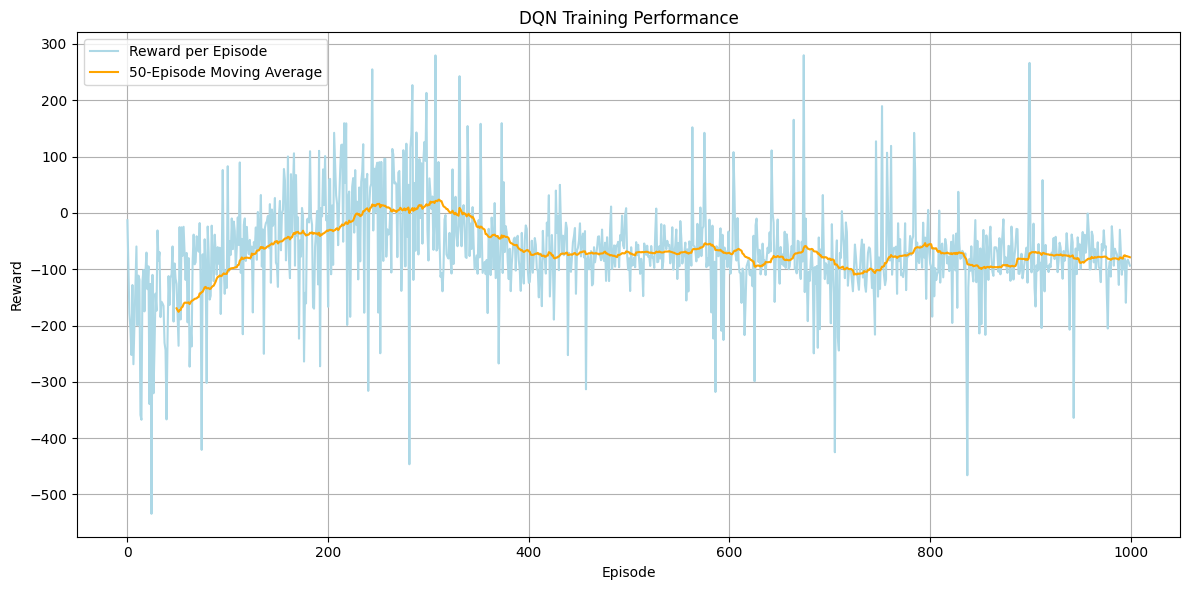

In [ ]:
plot_rewards(scores0)

- Sử dụng điểm thưởng của môi trường với learning rate = 0.001 và gamma = 0.99

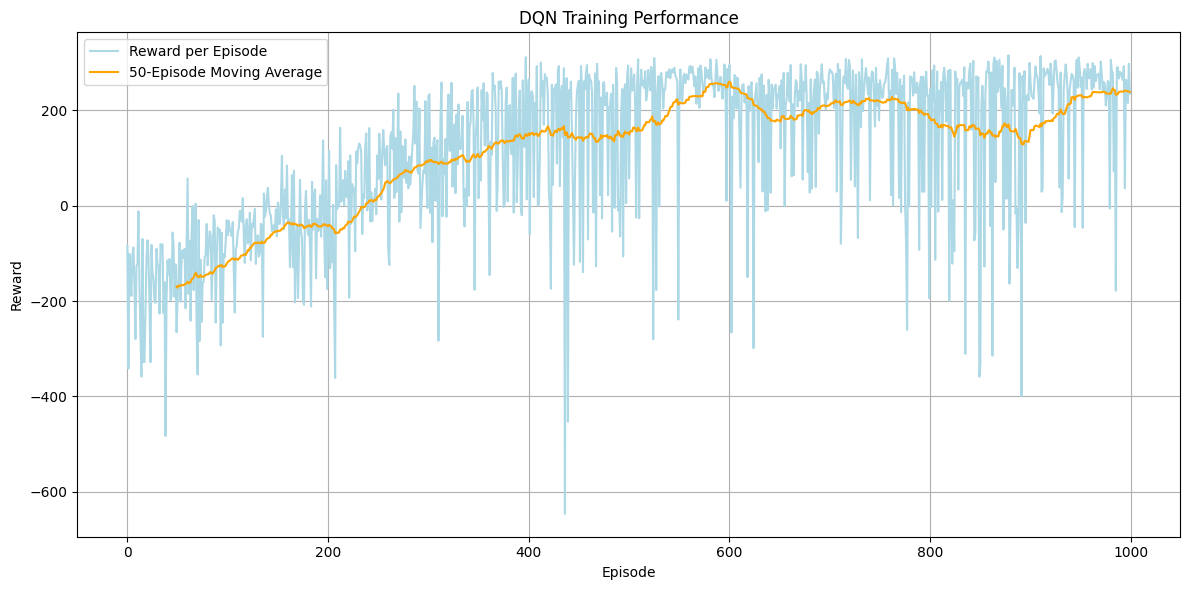

In [ ]:
plot_rewards(scores)

- Sử dụng điểm thưởng của môi trường với learning rate = 0.0001 và gamma = 0.99

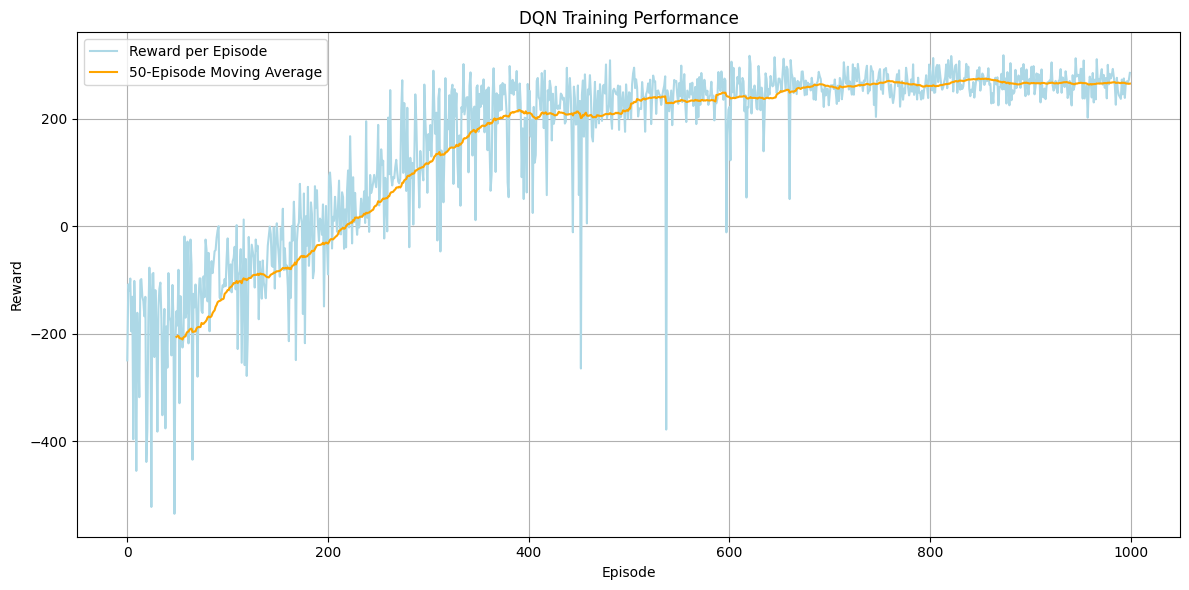

In [ ]:
plot_rewards(scores1)

- Sử dụng điểm custom

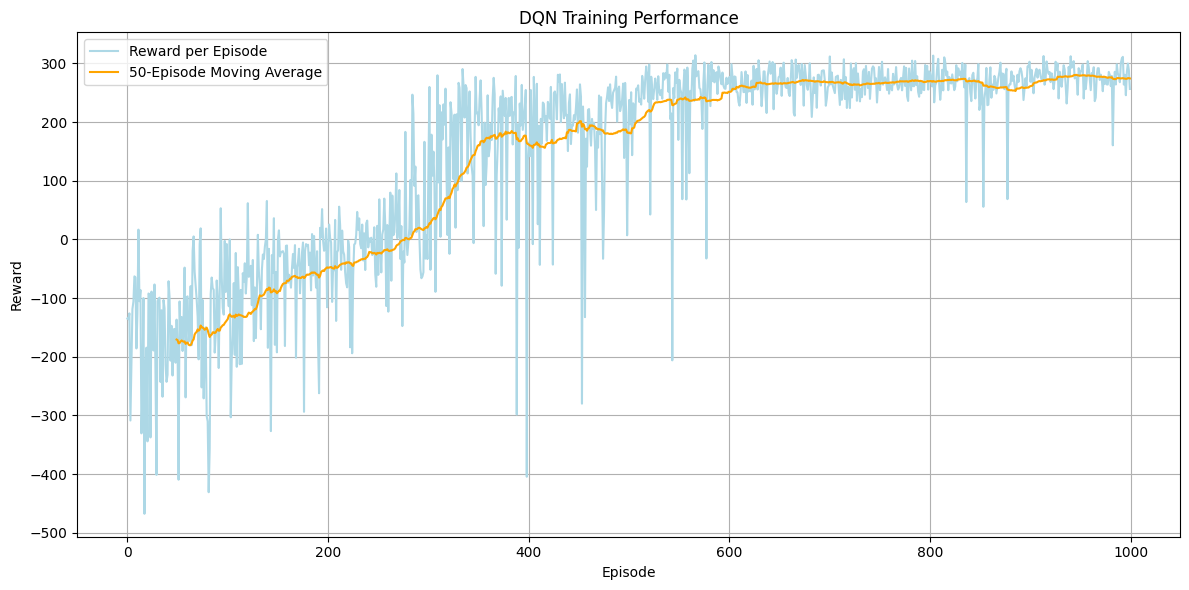

In [ ]:
plot_rewards(scores2)

### Nhận xét:
- Từ cả 3 biểu đồ trên, ta có thể thấy được DQN hoạt động khá tốt trong bài toán Lunar Lander ở cả hai trường hợp khi sử dụng reward gốc và các thông số hợp lí như learning rate đủ nhỏ và gamma = 0.99 của môi trường lẫn custom reward của bản thân.
- Từ hai biểu đồ ta có thể nhận thấy được Agent có khả năng học tốt từ 500 episodes đổ đi và đặc biệt đối với biểu đồ sử dụng reward của môi trường ta có thể thấy nó ổn định hơn so với custom reward
- Với biểu đồ của learning rate = 0.001 và gamma bằng 0.95 ta có thể thấy mô hình dao động rất mạnh, total_reward ở mức rất thấp nên cần điều chỉnh lại tham số để có thể học tốt hơn
- Với biểu đồ của learning rate = 0.001 và gamma = 0.99 đã có cải thiện tuy nhiên chúng ta vẫn cần chỉnh sửa để đạt hiệu quả tốt nhất như 2 đồ thị bên dưới bằng cách thay đổi learning rate

b. Video output của các trường hợp trên

- video của DQN sử dụng reward gốc với learning rate = 0.001 và gamma = 0.95

In [ ]:
show_video_of_model(policy_net0, 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


- Video của DQN sử dụng reward gốc với learning rate = 0.001 và gamma = 0.99

In [ ]:
show_video_of_model(policy_net, "LunarLander-v3", n_actions=env.action_space.n)
show_video()

- Video của DQN sử dụng reward gốc với learning rate = 0.0001 và gamma = 0.99

In [ ]:
show_video_of_model(policy_net1, 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


- Video của DQN sử dụng Custom reward

In [ ]:
show_video_of_model(policy_net2, 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


### Nhận xét:
- Các siêu tham số như learning rate và gamma ảnh hưởng cực lớn đến kết quả huấn luyện Agent, với các tham số không phù hợp như learning rate = 0.001 và gamma = 0.95 thì mô hình không học được và không thể hạ cánh phù hợp

c. Đánh giá tỉ lệ thành công và hiệu suất động cơ của hai trường hợp

- Sử dụng Reward gốc với learning rate = 0.001 và gamma = 0.95

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net0, n_episodes=100)


 Số lần hạ cánh thành công: 0/100 (0.00%)
Trung bình reward: -129.35
Hiệu suất nhiên liệu (reward per fuel unit): -0.47


- Sử dụng reward gốc với learning rate = 0.001 và gamma = 0.99

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net, n_episodes=100)


 Số lần hạ cánh thành công: 88/100 (88.00%)
Trung bình reward: 268.36
Hiệu suất nhiên liệu (reward per fuel unit): 2.94


- Sử dụng Reward gốc với learning rate = 0.0001 và gamma = 0.99

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net1, n_episodes=100)


 Số lần hạ cánh thành công: 93/100 (93.00%)
Trung bình reward: 249.63
Hiệu suất nhiên liệu (reward per fuel unit): 2.05


- Sử dụng Custom Reward

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net2, n_episodes=100)


 Số lần hạ cánh thành công: 98/100 (98.00%)
Trung bình reward: 274.16
Hiệu suất nhiên liệu (reward per fuel unit): 2.46


### Nhận xét:
- Sau khi chạy 2 hàm test ta có thể thấy được tỉ lệ hạ cánh thành công của Custom Reward tốt hơn so với khi sử dụng Reward gốc, Hiệu suất nhiên liệu của Custom reward cũng là tốt hơn

# Đánh giá kết quả thuật toán DDQN

a. So sánh biểu đồ điểm thưởng khi thay đổi learning rate và custom reward

1. Với learning rate = 0.001, gamma = 0.95 và sử dụng reward gốc

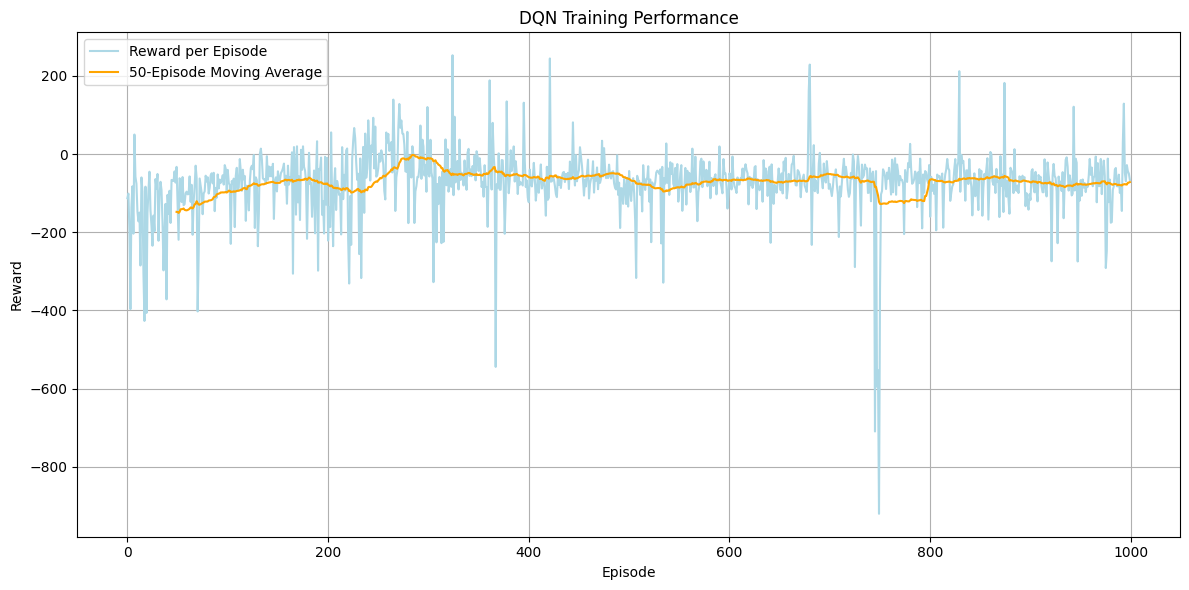

In [ ]:
plot_rewards(scores3)

2. Với Learning rate = 0.001 và gamma = 0.99, sử dụng reward gốc

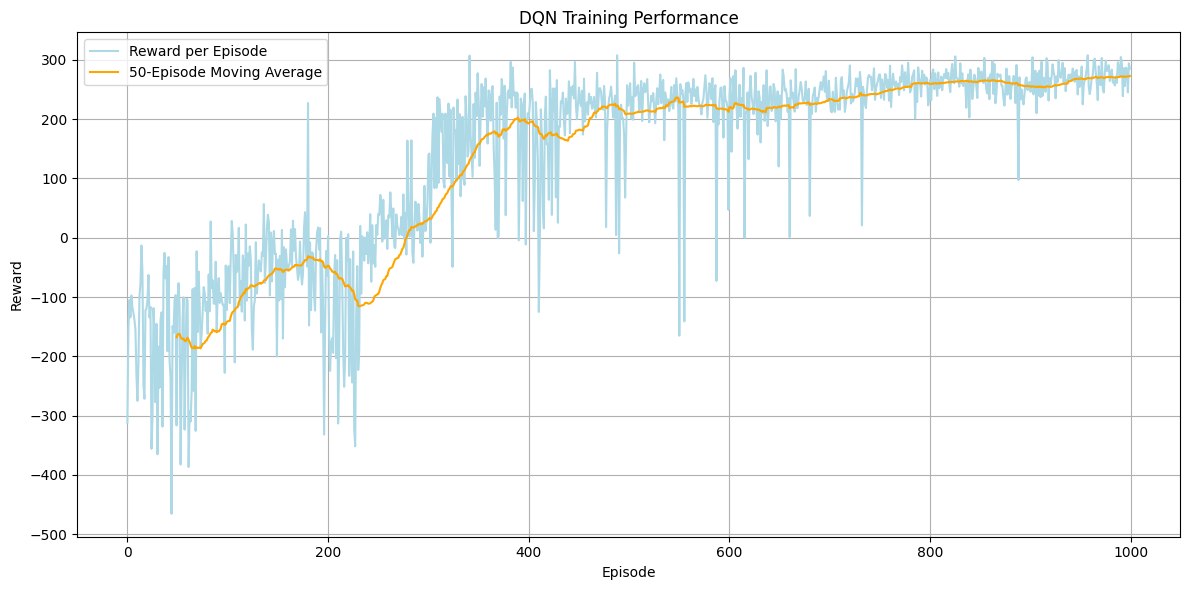

In [ ]:
plot_rewards(scores5)

3. Với learning rate = 0.0001 và sử dụng reward gốc

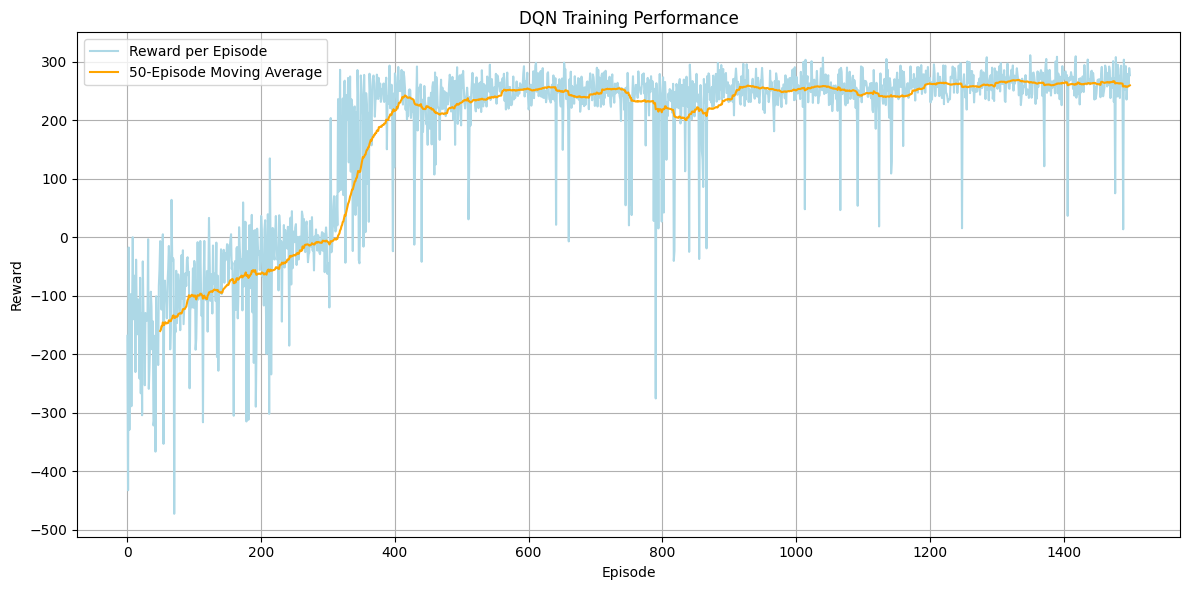

In [ ]:
plot_rewards(scores4)

4. Với learning rate = 0.0001 và sử dụng custom reward

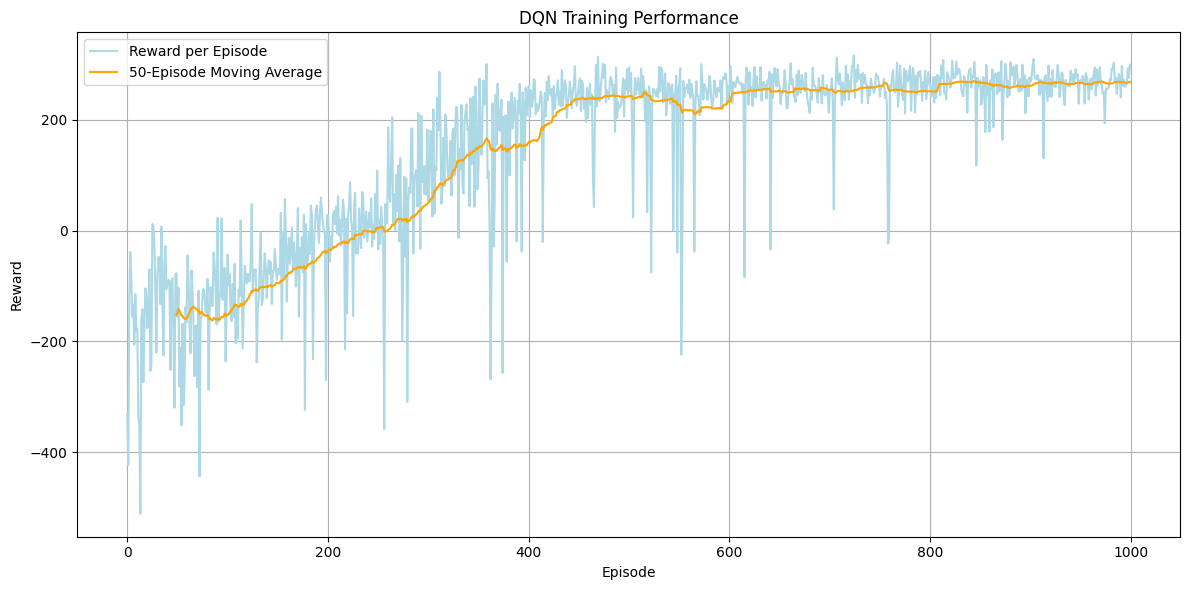

In [ ]:
plot_rewards(ddqn_custom_rewards1)

### Nhận xét:
- Với việc sử dụng learning rate = 0.0001 và reward gốc ta có thể thấy được DDQN cho ra một biểu đồ điểm thưởng đẹp và ổn định tuy nhiên ở các episode cuối có sự dao động nhẹ xuống dưới 200, điều này thể hiện vẫn cần cải thiện hơn về mặt ổn định
- Khi sử dụng custom reward ta thấy biểu đồ điểm thưởng khá ổn định, không có hiện tượng drop và càng về các episode cuối, biểu đồ càng hội tụ cho thấy mô hình hoạt động khá tốt

b. Video output của DDQN qua các trường hợp

1. Learning rate = 0.001 và sử dụng reward gốc

In [ ]:
show_video_of_model(policy_net3, 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


2. Learning rate = 0.001 và gamma = 0.99 đồng thời sử dụng reward gốc

In [ ]:
show_video_of_model(policy_net5, 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


3. Learning rate = 0.0001 và gamma = 0.99 đồng thời sử dụng reward gốc, nâng số episode lên 1500 để mô hình có thể học rộng hơn

In [ ]:
show_video_of_model(policy_net4, 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


4. Learning rate = 0.0001 và sử dụng custom reward

In [ ]:


# Hiển thị video
show_video_of_model(train_ddqn_custom1 , 'LunarLander-v3', n_actions=env.action_space.n)
show_video()


### Kết luận:
với bộ siêu tham số không hợp lí ta có thể thấy được mô hình học không được tốt dẫn đến việc Agent không thể hạ cánh đúng vị trí, tuy nhiên khi tinh chỉnh lại tham số thì quá trình học đã cải thiện và quá trình học tốt hơn

c. Đánh giá tỉ lệ thành công của 4 trường hợp

1. Với learning rate = 0.001 và gamma = 0.95

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net3, n_episodes=100)


 Số lần hạ cánh thành công: 0/100 (0.00%)
Trung bình reward: -84.72
Hiệu suất nhiên liệu (reward per fuel unit): -0.18


2. Với learning rate = 0.001 và gamma = 0.99

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net5, n_episodes=100)


 Số lần hạ cánh thành công: 92/100 (92.00%)
Trung bình reward: 252.73
Hiệu suất nhiên liệu (reward per fuel unit): 2.09


3. Với learning rate = 0.0001 và gamma = 0.99

In [ ]:
env = gym.make('LunarLander-v3')

successes, avg_reward, avg_fuel_efficiency, _, _ = test_success_rate(env, policy_net4, n_episodes=100)


 Số lần hạ cánh thành công: 94/100 (94.00%)
Trung bình reward: 259.54
Hiệu suất nhiên liệu (reward per fuel unit): 2.42


4. Với learning rate = 0.0001 và sử dụng custom reward

In [ ]:
env = gym.make("LunarLander-v3")
successes, avg_reward, fuel,_,_ = test_success_rate(env, train_ddqn_custom1, n_episodes=100)

 Số lần hạ cánh thành công: 98/100 (98.00%)
Trung bình reward: 266.98
Hiệu suất nhiên liệu (reward per fuel unit): 2.18


### Kết luận:
Hiệu suất mà mô hình mang lại khá ổn với tỉ lệ hạ cánh thành công cao. Trung bình điểm thưởng trên 260 và hiệu suất nhiên liệu ở mức ổn định. Tuy nhiên vẫn cần cải thiện để có thể nâng tỉ lệ hạ cánh lên cao hơn

# Kết luận:
- Mô hình giải quyết bài toán tốt nhất là DQN với custom reward và DDQN với custom reward cả hai đều mang đến tỉ lệ hạ cánh thành công là rất cao với 98%. Tuy nhiên có vẻ DQN với custom reward tốt hơn về mặt sử dụng động cơ.
- Cả hai mô hình DDQN và DQN cho thấy khả năng xử lí bài toán Lunar Lander là rất tốt với tỉ lệ hoàn thiện cao, điểm thưởng giao động thấp ở các episode cuối với reward của môi trường và total_reward ổn định ở mức trên 200 với giá trị tham số hợp lí
- Trong hàm test ta có thể thấy được khả năng sử dụng động cơ của mô hình DQN là nhỉnh hơn so với DDQN



# Khó khăn gặp phải:
1. DQN:
- Overestimation của giá trị Q:
  - DQN sử dụng cùng một mạng để chọn và đánh giá hành động. Điều này có thể khiến agent ưu tiên các hành động không thực sự tối ưu.
  => Agent có thể chọn những hành động không cần thiết
2. Dao động trong huấn luyện:
- Phải train qua rất nhiều lần để có thể có kết quả đẹp nhất:
  - Tương quan giữa các mẫu: mặc dù sử dụng Replay Buffer để giảm tương quan tuy nhiên việc lấy mẫu vẫn có thể không đủ ngẫu nhiên
  - Các siêu tham số có thể vẫn đang còn có thể tối ưu hơn được khi mà trong một số trường hợp đồ thị dao động mạnh khi train lại mô hình
  - Thời gian train là rất lâu để có thể mang lại kết quả đẹp nhất
3. Khó khăn khi dùng DDQN:
- Phức tạp hơn DQN, DDQN cần quản lý hai mạng tuy nhiên việc tinh chỉnh tham số dẫn đến khó khăn trong việc train do tốn nhiều thời gian để mang lại bộ tham số hợp lí nhất


# Đề xuất cải thiện

- Có thể sử dụng các thuật toán hiện đại như PPO và A2C ổn định hơn trong môi trường liên tục
- Có thể nâng episodes lên để agent học được nhiều kinh nghiệm hơn